<div align="center">
    <h1>Multimedia Communications - COMUL <br> & <br> Multimedia Systems - SISMUL</h1>
    <h2>Lab 5 - Introduction to Machine Learning:<br>parametric algorithms and supervised learning<br> (linear and logistic regression)</h2>
    <h4>Degree in Telecommunications and Informatics Engineering <br> & <br> Degree in Electrical And Computer Engineering</h4>
    <h5>
    <img width="500" src="img/logo_20230106.jpg"><br>
    2025 / 26</h5>
</div>

<div align="left">
    <h5>Authors: Luís Vilaça (snv@isep.ipp.pt), Paula Viana (pmv@isep.ipp.pt), Pedro Alves Guedes (peg@isep.ipp.pt)</h5>
</div>
---

In [5]:
# Imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle
import torch
import sys


# Seed initialization
SEED = 1234
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

### Introduction
Machine Learning (ML) is the scientific field whose goal is to develop methods and algorithms that "learn" from data. In other words, it aims to extraction information that resides in the data, which can than be posteriorly used to perform a given task.

In this context, data is commonly represented as a set of datapoints, e.g., $x_n, n = 1, 2,...,N$, where each $x_n$ is the set of variables (i.e., vector). The variables in $x_n$ are called the input variables, also known as the independent variables or features, and their respective vector is known as the feature vector.

#### Taxonomy of learning settings

ML methods can be divided according to what kind of data is available to leverage for analysis:
1. **Supervised Learning**: All available data is labelled and is represented in pairs of observations $(y_n, x_n)$, where $y_n$ are the target variables (i.e., output). Here, the learning goal is to map the relationship between input ($x$) and output ($y$) variables.
2. **Semi-supervised Learning**: Only a small subset of input variables have been labelled or they have been artificially labelled by another algorithm/method (pseudo-labels). The algorithm/approach needs to use that information to generalize for the entire dataset, because initially the labelled subset does not allow to obtain a good estimate of the input-output dependence.
3. **Self-supervised Learning**: Only the input variables are provided, but the algorithm assumes the data's structure as supervised information. For instance, audio and video appear together (i.e., structure), thus they have the same label for each video.
4. **Unsupervised Learning**: Only the input variables are provided and no output/label information is available.
5. **Reinforcement Learning**: This type of learning lies a set of rules and the goal is to learn sequences of actions that will lead an ("autonomous") agent to achieve its goal or to maximize its objective function. Intuitively, RL attempts to learn actions by trial and error. In contrast to supervised learning, optimal actions are not learned from labels but from what is known as a reward. This scalar value informs the system whether the outcome of whatever it did was right or wrong.

**In this lab script we will focus on Supervised learning methods to perform multiclass classification using the simpsons dataset (data that we used in the past).**

#### Taxonomy of models/algorithms

ML methods can also be classified according to the type of learning algorithms. This concerns the approach that is used within the algorithm to represent the pretended output and the relationships within the input elements. Typically, they can be divided into two main branches: probabilistic and non-probabilistic (or discriminative) methods. While the first type of methods relies on the conditioned probability formula to represent the uncertainty of the output the other ones use a more direct approach. The conditioned probability is used to represent the uncertainty of the output (represented as random variables) that is conditioned by the model's input ($p(y|x)$).

$$
p(C_k|x) = \frac{p(x|C_k)p(C_k)}{p(x)}
$$
- p(C_k|x): **Posterior probability**
- p(x|C_k): **Class conditioned probability** - probability of each attributes for each class ($C_k$), represents the variability of measurements
- p(C_k): Class prior - probability of the class itself, usually the frequencies in which it appears on the training set
- p(x) - Evidence - scale factor that guarantees that the posterior probabilities sum to one

Therefore, the taxonomy for the approaches is established as follows:

 1. **Discriminative Models**: 
    - No computation of posterior probabilities. These methods do not rely on the conditioned prob. formula.
    - Directly map each $x$ onto a class label
    - Example: Fisher's Linear Discriminant, Least Square Classification, SVM, etc
 2. **Probabilistic Models**: 
    - Computation of posterior probabilities
    1. **Probabilistic Discriminative Models**
       - Model posterior probabilities ($p(C_k|x)$) directly
       - Example: Logistic Regression
    2. **Probabilistic Generative Models**
       - Model class priors ($p(C_k)$) and conditional densities ($p(C_k|x)$)
       - Example: Naive Bayes

**In this lab script we will perform classification using the logistic regression, which is a probabilistic discriminative model. Additionally, we will also make a small demonstration using linear regression to get things started with the ML workflow.**

#### Common steps
The usual ML workflow follows these steps.
1. **Model representation**: how we represent the problem
2. **Evaluation**: how we evaluate the model
3. **Optimization**: how we optimize the model's output

#### Parameter Estimation

Given a set of datapoints, one must find a subspace that allows to describe the data. In other words, a curve or surface that "fits" the data. Usually, you can adopt a functional form (e.g., linear or polinomial one) and try to estimate its parameters so that its output "passes through" the data and follows its pattern as close as possible. The task comprises two steps:
1. Adopt a specific parametric functional form which we find to be more appropriate for the problem at hand
2. Estimate the values of the unknown parameters in order to obtain a "good" fit

- Model Representation
The choice of which function ($\mathcal{F}$) to model the data is not an easy task. In practice, you need to use as much a priori information as possible concerning the physical mechanism that underlies the data generating process/distribution. Let's consider $y \in \mathcal{R}$ as our output variable and $\hat{\theta}$ as our model's parameters and the output of our estimation process. Choosing the model representation is choosing the family of functions that allows to best represent our data and leads to the best performance. 

- Evaluation
After choosing a family of functions (parametric family of functions - $\mathcal{F}$), we need to get estimates for the set of unknown parameters. We need to adopt a measure of fitness (ability that a ML model has of approaximating the data). The classical approach is to adopt a loss function, which quantifies the deviation/error between the measured value of $y$ and the predicted one using the corresponding measurements $x$. 

- Optimization
This loss function must be a nonnegative function. By minimizing the total error (loss) over all datapoints we can obtain an approximate value for the model's parameters ($\hat{\theta}$). Depending on the model's output (parametric families of functions), you can use different loss functions.

In this lab script, we will see two examples:
1) **Linear Regression**: Uses the **Squared Error** loss function.
2) **Logistic Regression**: Uses the **Negative Log-Likelyhood** loss function. This is the probabilistic equivalent to the squared error that measures the error between probability distributions (*we will see an example of this later in the lab script*).


<div align="center">
    <img width="800" src="img/ml_map.png"><br>
    <h10>(Image taken from: sklearn website)</h10>
</div>


#### Validation

From the theoretical lectures, you might already depicted that a "good" estimate according to one set of training points is not necessarily a good one for other datasets (in production). This is an important aspect in any ML task, because the performance of a method may vary with the random choice of the training set. Therefore, a major phase, in any machine learning task, is to quantify/predict the performance that the designed (prediction) model is expected to exhibit in practice. 

It will not come as a surprise that "measuring" the performance against the training data set would lead to an "optimistic" value of the performance index, because this is computed on the same set on which the estimate was optimized. Moreover, if the model is complex enough, with a large number of free parameters, the training error may even become zero, since a perfect fit to the data can be achieved. It is more fair to compute the model's average performance over different data sets which did not participate in the training phase. The error associated with this average performance is known as the test error.

The error measured on the (single) training data set is shown together with the (average) test error as the model complexity varies in the following figure.
<div align="center">
    <img width="800" src="img/validation.png"><br>
    <h10>(Image taken from: Machine learning: a Bayesian and optimization perspective by Sergios Theodoridis)</h10>
</div>

If one tries to fit a complex model, with respect to the size of the available training set, then the error measured on the training set will be overoptimistic. On the contrary, the **true error**, as this is represented by the test error, takes large values. On the other hand, if the model is too simple the test error will also attain large values. **The idea is to have a model complexity that corresponds to the minimum of the respective curve.**

All in all, we must have a way to test the performance of an obtained classifier/predictor using different datasets. This process is known as **validation**, and there are a number of alternatives that one can resort to. The most basic methodology is to have three types of datasets: **training**, **validation** and **test**.
1) **training** set: used to optimize the model
2) **validation** set: used to validate the training hyperparameters (can be constructed using the training set)
3) **test** set: used to perform benchmark (**always** a separate set)

### 1. Regression

Regression is a task of modelling the relationship of a dependent random variable $y$ and a set of random variables $x_1, x_2,...,X_l$ (random vector $x$). The goal of the regression task is to estimate the parameter vector $\theta$, given a set of measurements/observations $(y_n, x_n), n = 1, 2,...,N$ that we have at our disposal. This is also known as the **training data set**.

#### 1.1. Linear Regression
 
In this example **we try to solve a regression problem** where we want to **predict the housing price based on certain factors like the age of the house**. 

**Can you overcome these obstacles & build a decent predictive model?**

First, load the necessary data.

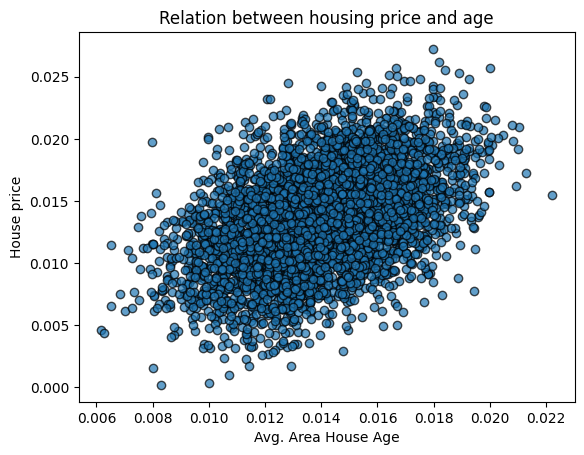

In [24]:
import torch.nn.functional as F

def normalize_data(X):
    return F.normalize(X, dim=0)

# Load data for regression

# use the load function from Numpy
X = torch.Tensor(np.load('data/usa_housing_data2.npy')[:, 1])[:, None]
y = torch.Tensor(np.load('data/usa_housing_data2.npy')[:, -1])

# used to normalize the input data between [0, 1]
X = normalize_data(X)
y = normalize_data(y)

# visualize the data
plt.scatter(X, y, alpha=0.7, edgecolors="k")
plt.title("Relation between housing price and age")
plt.xlabel("Avg. Area House Age")
plt.ylabel("House price")
plt.show()

##### 1.1.1. Model Representation
The linear regression model assumes that the output ($y$) has a linear relationship with the input ($x$) as such
$$
y = \theta_0 + \theta_1x_1 + ... + \theta_lx_l = \theta_0 + \theta^TX + \eta,
$$
where $\eta$ is the noise term that represents an additive disturbance in the measurements (data) and $\theta_0$ the bias parameter.

Therefore, you can write
$$
\theta_0 + \theta^TX + \eta = \begin{bmatrix}\theta^T & \theta_0\end{bmatrix}\begin{bmatrix} X \\ 1 \end{bmatrix} + \eta \equiv y = \theta^TX + \eta
$$

Observe that the bias variable as been absorved by $\theta$.  Because the noise variable is unobserved, we only need a model to be able to predict the output value of $y$, so the model with the estimated weights is represented only by $\theta$ and $X$:
$$
\hat{y} = \hat{\theta}^TX
$$

With all this in mind we can implement the linear regression model.

In [25]:
# Linear Regression
def linear_regression(X, theta):
    pred_y = X @ theta.t()
    return pred_y.squeeze() # remove extra dims.

# include the bias vars
bias = torch.ones(X.shape[0], 1).float()
X = torch.cat((bias, X), axis=1)
print(f"Input (including the bias var): \n{X}, with shape {X.shape}")

# create training variables
theta = torch.randn(1, X.shape[1], requires_grad=True)
print(f"Theta: {theta}, with shape {theta.shape}")

Input (including the bias var): 
tensor([[1.0000, 0.0133],
        [1.0000, 0.0140],
        [1.0000, 0.0137],
        ...,
        [1.0000, 0.0169],
        [1.0000, 0.0129],
        [1.0000, 0.0140]]), with shape torch.Size([5000, 2])
Theta: tensor([[0.0461, 0.4024]], requires_grad=True), with shape torch.Size([1, 2])


In [26]:
# get sample outputs
pred_y = linear_regression(X, theta)
pred_y

tensor([0.0515, 0.0518, 0.0516,  ..., 0.0529, 0.0513, 0.0518],
       grad_fn=<SqueezeBackward0>)

In [27]:
# You can also create the model using Torch's model structure (torch.nn.Module).
class LinearRegression(torch.nn.Module):
    def __init__(self, no_params):
        super(LinearRegression, self).__init__()
        self.theta = torch.randn(1, no_params, requires_grad=True)

    def forward(self, input):
        return (input @ self.theta.t()).squeeze() # remove extra dims.


l_reg = LinearRegression(X.shape[1])
pred_y = l_reg(X)
pred_y

tensor([-1.0087, -1.0085, -1.0086,  ..., -1.0079, -1.0087, -1.0085],
       grad_fn=<SqueezeBackward0>)

##### 1.1.2. Evaluation

To evaluate the quality of fit we will use the Mean Squared Error (MSE) over all observations.
$$
MSE = \frac{1}{N}\sum_{i=1}^{N} (y_n - \hat{y})^2
$$

The next cell provides the code for computing the MSE.

In [28]:
# MSE
def mse(t1, t2):
    return ((t1 - t2) ** 2).mean()

# cost of untrained model
cost = mse(y, pred_y)
print(f"Cost of untrained model: {cost}")

Cost of untrained model: 1.044702410697937


##### 1.1.3. Optimization

Using the MSE loss function we can obtain an estimate for $\theta$. This is done by minimizing the squared difference between $\hat{y}$ (predicted output) and the real $y$ over the set of available observations. 

The function to minimize is:
$$
J(\theta) = \sum_{n=1}^{N} (y_n - \theta^{T}x_n)^2
$$

Therefore, we need to search in the parameter space ($\mathcal{R^k}$) for the solution that best fits our problem. 

You might already know that you can do this through the derivative. If we take the derivative with respect to $\theta$ and equating to $0$ we can obtain the global minimum. 

**We will leave here the complete derivation of the loss function, but do not worry about these details...**
$$
L(y, \hat{y}) = (y - \hat{y})^2 \\
J(\theta) = \frac{1}{N} \sum_{n=1}^{N} L(y, \hat{y}) = \frac{1}{N} \sum_{n=1}^{N} (y - \hat{\theta}^TX)^2 = \\
= \frac{1}{N} (y - X\hat{\theta})^T(y - X\hat{\theta}) = \frac{1}{N} (y^Ty -2\hat{\theta}^TX^Ty + \hat{\theta}^TX^TX\hat{\theta})
$$
$$
\frac{\partial J}{\partial \hat{\theta}} = 0 \Leftrightarrow \frac{1}{N} \frac{\partial}{\partial \hat{\theta}}  [ y^Ty -2\hat{\theta}^TX^Ty + \hat{\theta}^TX^TX\hat{\theta} ] = 0 \Leftrightarrow X^TX\hat{\theta} = X^Ty \Leftrightarrow \hat{\theta} = (X^TX)^{-1}X^Ty
$$

Computing this equation will give us the optimal values for $\theta$ (i.e., normal equation). However, you can also use an iterative approach for finding the solution as you saw in the theoretical lectures (i.e., gradient descent). You can use the step derived above to optimize the weights and, at each step, update the weights using the following rule: $\theta = \theta - \eta\nabla J(\theta) =  \theta - \eta(-2X^Ty + 2X^TX\hat{\theta})$

In the next cell, ewe will perform **estimate the coeficients for the linear regression model using two optimization methods**: **normal equation** (analitical answer, described above) and **gradient descent** with *Pytorch's automatic differentiation*.

In [29]:
class LinearRegression(torch.nn.Module):
    def __init__(self, no_params):
        super(LinearRegression, self).__init__()
        self.no_params = no_params
        self.theta = torch.randn(1, no_params, requires_grad=True)

    def forward(self, input):
        return (input @ self.theta.t()).squeeze() # remove extra dims.

    def _reset_weights(self):
        self.theta = torch.randn(1, self.no_params, requires_grad=True)
    
    def _normal_equation(self, X, y):
        with torch.no_grad():
            self.theta = torch.inverse(X.t() @ X) @ X.t() @ y

In [30]:
# Estimate the weights using the normal equation (LeastSquares)

l_reg = LinearRegression(X.shape[1])
l_reg._normal_equation(X, y)

print(f"Theta: {l_reg.theta}")
print(f"Normal Equation - cost/error: {mse(y, l_reg(X))}")  # the cost is very close to 0

Theta: tensor([0.0030, 0.7620])
Normal Equation - cost/error: 1.207009881909471e-05


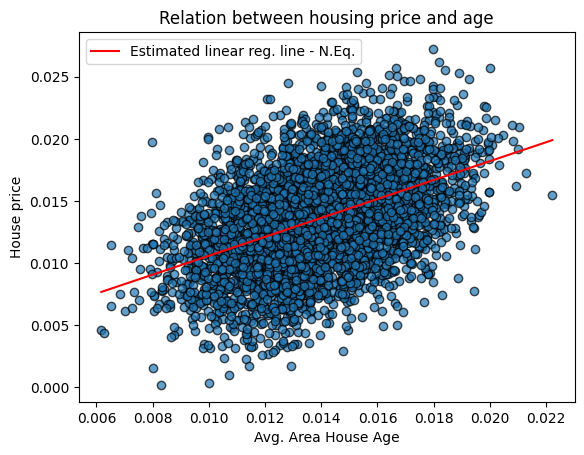

In [31]:
plt.scatter(X[:, 1], y, alpha=0.7, edgecolors="k")
plt.plot(
    [X[:, 1].min(), X[:, 1].max()], 
    [l_reg(torch.tensor([1., X[:, 1].min()])).detach(), l_reg(torch.tensor([1., X[:, 1].max()])).detach()],
    '-r',
    label='Estimated linear reg. line - N.Eq.'
)
plt.title("Relation between housing price and age")
plt.xlabel("Avg. Area House Age")
plt.ylabel("House price")
plt.legend()
plt.show()

In [32]:
# Estimate the weights using Gradient Descend - iterative approach

l_reg._reset_weights()

steps = 6000
lr = 0.01

def loss_fn(y, y_pred):
    return ((y_pred - y) ** 2).mean()

for i in range(steps):     
    # forward pass - get prediction
    y_pred = l_reg(X)
    
    # using torch's autodiff and perform backpropagation - get grads
    loss = loss_fn(y, y_pred)
    loss.backward()
        
    with torch.no_grad():
        # update the weights (theta)
        l_reg.theta -= lr * l_reg.theta.grad

        # set gradients to 0 (reset process)
        l_reg.theta.grad.zero_()
    
    sys.stdout.write(f"iter {i}/{steps} - theta: {l_reg.theta.detach().numpy()} loss: {loss.detach().numpy():.7f} error: {mse(y, y_pred):.5f}\r")
    sys.stdout.flush()


print(f"\nTheta: {l_reg.theta.detach().numpy()}")
print(f"Gradient Descent - cost/error: {mse(y, l_reg(X))}") 

iter 5999/6000 - theta: [[0.00396954 0.6899144 ]] loss: 0.0000121 error: 0.00001
Theta: [[0.00396954 0.6899144 ]]
Gradient Descent - cost/error: 1.209787751577096e-05


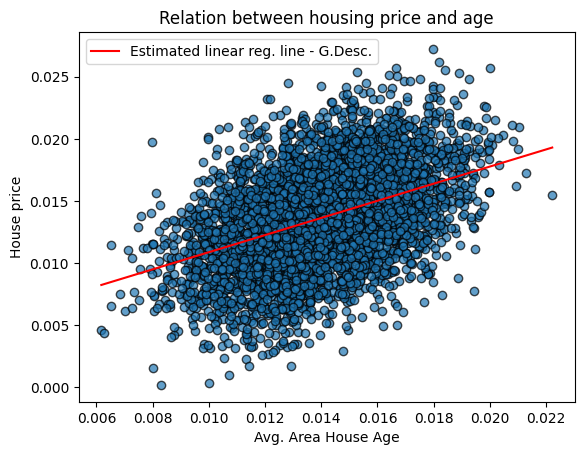

In [33]:
plt.scatter(X[:, 1], y, alpha=0.7, edgecolors="k")
plt.plot(
    [X[:, 1].min(), X[:, 1].max()], 
    [l_reg(torch.tensor([1., X[:, 1].min()])).detach(), l_reg(torch.tensor([1., X[:, 1].max()])).detach()],
    '-r',
    label='Estimated linear reg. line - G.Desc.'
)
plt.title("Relation between housing price and age")
plt.xlabel("Avg. Area House Age")
plt.ylabel("House price")
plt.legend()
plt.show()

### 2. Classification

Classification is the task of predicting the class to which a datapoint belongs. **One of the early stages in designing a classification system is to select an appropriate set of feature variables. These should "encode" as much class-discriminatory information so that, by measuring their value for a given datapoint, we are able to predict, with high enough probability, the class of the pattern.** Selecting the appropriate set of features for each problem is not an easy task, and it comprises one of the most important areas within the field of ML.

After selecting the most important features (random variables), we can stack them together to build the feature vector ($x \in \mathcal{R}^l$) for each datapoint (e.g., image). **The goal is to design a classifier that is able to represent a decision surface (or function) to that we can predict the class to which the values in a feature vector belong.**

Each **class label** is represented by a **discrete set of variables**. 

- For the simple binary classification problem (i.e., two classes), this can either take two values, 0 or 1. 
- For a multi-class classification problem the size of the set of variables increases (e.g., {0, 1, 2, 3}).

Similar to the regression example, we will follow a **parametric approach to the problem**. Therefore, we want to estimate the parameters of a function $f()$, based on a set of training datapoints, so that the deviation between the true class labels, $y_n$, and the predicted ones, $\hat{y}_n$, is minimum. In this case, out dependent variables ($y$) are discrete. Therefore, we need to use the probability of the error to optimize the parameters as we will see in the next example.

As already been referred, the goal of a classifier is to partition the input space into regions and associate each region with a class. The following figure illustrates two cases of classification tasks:
1) The first one is an example of two linearly separable classes, where a straight line can separate the two classes.
2) The second case is an example of two nonlinearly separable classes, where the use of a linear classifier would have failed to separate the two classes.

Please notice that the classification algorithm can also be divided by the complexity of decision lines they can produce (linear and non-linear).

<div align="center">
    <img width="1000" src="img/cls_lines.png"><br>
    <h10>(Image taken from: Machine learning: a Bayesian and optimization perspective by Sergios Theodoridis)</h10>
</div>

Consider the (A) example from the figure above. We are given a set of training data that belongs to either of two classes. The goal is to design a hyperplane that separates the two classes. So, any point lying on this hyperplane scores a zero, $f(x) = 0$, and the points lying on either side of the hyperplane score either a positive ($f(x) > 0$) or a negative value (f (x) < 0), depending on which side of the hyperplane they lie. 

**This is done by minimizing the probability of error**, in other words, the percentage of points for which the true labels $y_n$ and the ones predicted by the classifier, $\hat{y}_n$ are different. The path we have chosen in terms of type of learning tool to use is **discriminative learning**. Thus, we are considering a functional dependence between $y$ and $x$ and **we are not concerned with the statistical nature that lies between this dependency**. This is due to the fact that we are directly modelling the posterior probability without even looking at the distribution of the input data.

In a more general setting, the term **probabilistic discriminative learning** is also used to cover methods that model directly the **posterior probability of a class**, represented by its label $y$, given the feature vector $x$, as in $p(y|x)$.

The relevant characteristic of all these methods is that they bypass the need of modeling the input data distribution explicitly. In this case a functional form is adopted as follows:
$$
p(y|x; \theta)
$$

Parameters are then estimated by optimizing a cost function. The distribution of the input data is ignored. Such an approach has the advantage that simpler models can be used, especially if the input data are described by a joint probability density function (PDF) of a complex form. However, the input data distribution is ignored.

#### 2.3. Logistic Regression

The goal in this section is to **model the posterior probabilities directly via the logistic regression method**. In this example we try to solve a classification problem where **we want to classify between the three species of plants based on certain features such as the petals width and length**. 

**Can you build a decent predictive model?**

First, load the necessary data.

label_map (different y values correspond to): {0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}
Types of features used: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


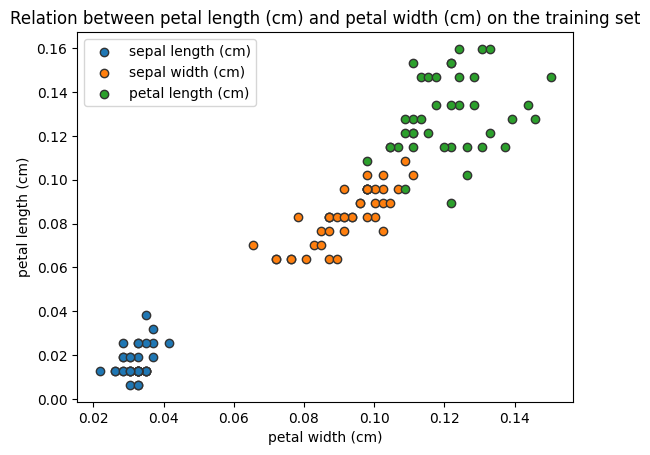

In [34]:
import torch.nn.functional as F

def normalize_data(X):
    return F.normalize(X, dim=0)


# Load iris dataset (already preprocessed and divided into train and test)
with open('data/iris.pkl', 'rb') as f:
    ((X_train, y_train), (X_test, y_test), label_dict, feature_names)= pickle.load(f)

print(f"label_map (different y values correspond to): {label_dict}")
print(f"Types of features used: {feature_names}")

X_train = torch.Tensor(X_train)
X_test = torch.Tensor(X_test)
y_train = torch.Tensor(y_train)
y_test = torch.Tensor(y_test)

# Normalize data
X_train = normalize_data(X_train)[:, [2, 3]]
X_test = normalize_data(X_test)[:, [2, 3]]

# visualize the data - only used 2 features
data_0 = X_train[y_train.squeeze() == 0]
data_1 = X_train[y_train.squeeze() == 1]
data_2 = X_train[y_train.squeeze() == 2]

# different colors for each class label
plt.scatter(data_0[:,0], data_0[:,1], edgecolor="#333", label=feature_names[0])
plt.scatter(data_1[:,0], data_1[:,1], edgecolor="#333", label=feature_names[1])
plt.scatter(data_2[:,0], data_2[:,1], edgecolor="#333", label=feature_names[2])

plt.title(f"Relation between {feature_names[2]} and {feature_names[3]} on the training set")
plt.ylabel(feature_names[2])
plt.xlabel(feature_names[3])
plt.legend(loc="upper left")
plt.show()

The output labels must be encoded in the following format because your model's output is a probabilistic distribution over all classes:
$$
y = \begin{bmatrix} 1 \\ 2 \\ 0 \\ ...\end{bmatrix} = \begin{bmatrix} 0 & 1 & 0 \\ 0 & 0 & 1 \\ 1 & 0 & 0 \\ ...\end{bmatrix} 
$$
This is called one hot encoding.

In [35]:
# One hot encoding
y_train = F.one_hot(y_train.squeeze().to(torch.int64)).float()
y_test = F.one_hot(y_test.squeeze().to(torch.int64)).float()
print(y_train[0, :], y_test[0, :])

tensor([0., 0., 1.]) tensor([0., 1., 0.])


##### 2.3.1. Model Representation

For the **binary classification** scenario we model the ratio of the posteriors as:
$$\log \frac{p(1|X)}{p(0|X)} = \theta^TX,$$
where the sum of probabilities sums to 1: $p(1|X) + p(0|X) = 1$

To this purpose we use the **logistic sigmoid function**. If we model each of the posterior probabilities we obtain something similar to:
$$
p(1|X)=\frac{1}{1 + e^{-\theta^TX}}, \quad p(0|X) = 1 - p(1|X) = \frac{e^{-\theta^TX}}{1 + e^{-\theta^TX}}
$$

The logistic regression formulation only involves $l + 1$ parameters. **This model is a model that produces linear decision boundaries**, which can be inferred by the dependency between weights ($\theta^TX$).

For the **multi-class classification** scenario, we generalize the function to allow **K classes** and obtain:
$$
\hat{y}_k = p(y_k|X) = softmax(z) = \frac{e^{-\theta^{T}_{k}X}}{\sum_{j=1}^{K} e^{-\theta^{T}_{j}X}}
$$
This is how the logistic regression model allows to obtain a decision boundary for each class. **The relation between posteriors is modelled as a binary classification problem between one class and the others (one vs all)** as follows:
$$
\log \frac{p(y_k|X)}{p(y_K|X)} = \hat{\theta}_{k}^TX
$$
In this case, the output of the model is a vector of K probabilities and for each one we have a weight associated.

In the following cells we will illustrate how you can implement the logistic regression function:

In [36]:
# include the bias vars
bias_train = torch.ones(X_train.shape[0], 1).float()
bias_test = torch.ones(X_test.shape[0], 1).float()
X_train = torch.cat((bias_train, X_train), axis=1)
X_test = torch.cat((bias_test, X_test), axis=1)
print(f"Train input (including the bias var): {X_train[0, :]}, with shape {X_train.shape}")
print(f"Test input (including the bias var): {X_test[0, :]}, with shape {X_test.shape}")

# create training variables
theta_binary = torch.randn(1, X_train.shape[1], requires_grad=True)
print(f"Theta (binary): {theta_binary}, with shape {theta_binary.shape}")
theta_mclass = torch.randn(y_train.shape[1], X_train.shape[1], requires_grad=True)
print(f"Theta (multiclass): {theta_mclass}, with shape {theta_mclass.shape}")

Train input (including the bias var): tensor([1.0000, 0.1329, 0.1213]), with shape torch.Size([120, 3])
Test input (including the bias var): tensor([1.0000, 0.2248, 0.1985]), with shape torch.Size([30, 3])
Theta (binary): tensor([[-0.2669,  2.1785,  0.1021]], requires_grad=True), with shape torch.Size([1, 3])
Theta (multiclass): tensor([[-0.2590, -0.1549, -1.3706],
        [-0.1319,  0.8848, -0.2611],
        [ 0.6104, -0.0098, -1.4473]], requires_grad=True), with shape torch.Size([3, 3])


In [37]:
# Logistic Regression

def sigmoid(z): # for binary classification
    return 1/(1 + torch.exp(-z))

def softmax(z): # for multiclass classification
    return torch.exp(z) / torch.exp(z).sum(1).unsqueeze(1)


def binary_logistic_regression(X, theta):
    # dont forget to absorve theta0 into theta
    pred_y = X @ theta.t()
    return sigmoid(pred_y.squeeze()) # remove extra dims.


def multiclass_logistic_regression(X, theta):
    # dont forget to absorve theta0 into theta
    pred_y = X @ theta.t()
    return softmax(pred_y.squeeze()) # remove extra dims.

In [38]:
# get sample outputs

# Binary classification
pred_y = binary_logistic_regression(X_train, theta_binary)
print(f"Binary classification output example (for the first datapoint): {pred_y[0].detach()}")

# Multiclass classification
pred_y = multiclass_logistic_regression(X_train, theta_mclass)
print(f"Multiclass classification output example (for the first datapoint): {pred_y[0, :].detach()}")

Binary classification output example (for the first datapoint): 0.5087478756904602
Multiclass classification output example (for the first datapoint): tensor([0.2040, 0.3043, 0.4916])


In [39]:
# You can also create the model using Torch's model structure
class LogisticRegression(torch.nn.Module):
    def __init__(self, no_params, no_classes):
        super(LogisticRegression, self).__init__()
        self.theta = torch.randn(no_classes, no_params, requires_grad=True)
        self.no_classes = no_classes

    def forward(self, X):
        z = X @ self.theta.t()
        if self.no_classes > 1:
            return softmax(z.squeeze())
        else:
            return sigmoid(z.squeeze())


log_reg = LogisticRegression(X_train.shape[1], y_train.shape[1])
y_pred = log_reg(X_train)
print(f"Classification output example (for the first datapoint): {y_pred[0, :].detach()}")

Classification output example (for the first datapoint): tensor([0.2575, 0.5971, 0.1454])


##### 2.3.2. Evaluation

To evaluate the performance of the model we use the **error between class assignments**.

This is commonly referred as **accuracy** and it is calculated as follows:
$$
Acc(y, \hat{y}) = \frac{\text{correct classifications}}{\text{all classifications}} 
$$


The next cell gives you an example on how to implement it.

In [40]:
# Accuracy
def accuracy(y_true, y_pred):
    if y_pred.shape[1] == 1: # binary multiclass
        return (y_true == y_pred).float().mean()
    else:
        return (torch.argmax(y_true, 1) == torch.argmax(y_pred, 1)).float().mean()

# cost of untrained model
cost = accuracy(y_train, y_pred)
print(f"Accuracy of the untrained model: {cost}")

Accuracy of the untrained model: 0.36666667461395264


##### 2.3.3. Optimization

- Maximum Likelihood Estimation

Consider a set of $N$ observations, $\mathcal{X} = {x_1, ..., x_n}$ drawn from a probability distribution. We assume that the joint probability density function (PDF) of these N observations is of a known parametric functional type, denoted as $p(X; \theta)$, where the task is to estimate $\theta$. This joint PDF is known as the **likelihood function of θ** with respect to the given set of observations $X$. 

According to the Maximum Likelihood method, the estimate is provided by:
$$
\hat{θ}_{ML} = \argmax_{\theta \in \mathcal{R}^k}{p(X; \theta)}
$$

In other words, given our dataset, one selects $\theta$ so as to make this joint PDF the most likely one to happen. Because the logaritmic function ($\ln()$) is monotone and increasing, we can search instead for the maximum using its output, thus we end up using the **negative log-likelyhood** (**we use the negative because we want to find the maximum so we invert the function**) function. 

This is achieved through the derivative once more, as follows:
$$
\frac{\partial \log p(X; \theta)}{\partial \theta}|_{\theta = \hat{\theta}_{ML}} = 0
$$

- How to optimize our model's weights?

Optimization is done through the **log-likelihood function**, which measures the difference/error between probability distributions. If we consider that our model's output is probabilistic distribution over all possible classes, we can calculate it as follows:

1) For the binary classification scenario we use the **Sigmoid function** that produces a decimal between 0.0 and 1.0. For example, if this function outputs 0.8, in an email classification scenario, it suggests an 80% chance of an email being spam and a 20% chance of it being not spam. Clearly, the sum of the probabilities of an email being either spam or not spam is 1.0.
    $$
    \hat{y}_k = sigmoid(z) = \frac{1}{1 + e^{-(\theta^TX)}}
    $$

    Therefore, the negative log-likelihood for this case takes the form of
    $$
    NNL(y, \hat{y}; \theta) = -\log \prod_{n=1}^{N} p_\theta(y^n|x^n) = -\sum_{n=1}^{N} \log p_\theta (y^n|x^n) = -\sum_{n=1}^{N} \sum_{k=1}^{K}  y_{k}^{n} \log \hat{y}_{k}^{n} = \\
    = - \sum_{n=1}^{N} [y^{n} \log(\hat{y}^{n}) + (1 - y^{n})\log(1 - \hat{y}^{n})]
    $$

2) In multiclass classification, we use the **Softmax function** to assign decimal probabilities to each class. Those decimal probabilities must add up to 1.0.
    $$
    \hat{y}_k = softmax(z) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
    $$
    Therefore, the negative log-likelihood for this case takes the form of
    $$
    NNL(y, \hat{y}; \theta) = -\log \prod_{n=1}^{N} p_\theta(y^n|x^n) = -\sum_{n=1}^{N} \log p_\theta (y^n|x^n) = -\sum_{n=1}^{N} \sum_{k=1}^{K}  y_{k}^{n} \log \hat{y}_{k}^{n}
    $$

For both cases we do not need to derivate everything by hand, we can rely on Pytorch's autodiff to do that. In the next cells, we will **estimate the coeficients for the multiclass logistic regression model using  gradient descent**. You will see that after each iteration we need to evaluate the model against an unknown dataset (testset) in order to understand if the model is progressing well during the optimization process. 

In [41]:
# create model using torch's modules

class LogisticRegression(torch.nn.Module):
    def __init__(self, no_params, no_classes):   
        super(LogisticRegression, self).__init__()
        self.theta = torch.randn(no_classes, no_params, requires_grad=True)
        self.no_classes = no_classes
        self.no_params = no_params

    def forward(self, input):
        z = input @ self.theta.t()

        if self.no_classes > 1:
            return self.softmax(z.squeeze())
        else:
            return self.sigmoid(z.squeeze())
    
    def _reset_weights(self):
        self.theta = torch.randn(self.no_classes, self.no_params, requires_grad=True)
        
    def sigmoid(self, z):
        return 1/(1 + torch.exp(-z))

    def softmax(self, z):
        return torch.exp(z) / torch.exp(z).sum(1).unsqueeze(1)


log_reg = LogisticRegression(X_train.shape[1], y_train.shape[1])

In [42]:
# Estimate the weights using Gradient Descend - iterative approach
steps = 2000
lr = 0.1

def loss_fn_multiclass(y_true, y_pred): 
    # negative log-likelihood (cross-entropy)
    return -(y_true * torch.log(y_pred)).sum(1).mean()


log_reg._reset_weights()

# training
for i in range(steps):
    # forward pass - get prediction
    train_pred = log_reg(X_train)

    # get grads
    train_loss = loss_fn_multiclass(y_train, train_pred)
    train_loss.backward()
    
    with torch.no_grad():
        # update the weights (theta)
        log_reg.theta -= lr * log_reg.theta.grad

        # set gradients to 0 (reset process)
        log_reg.theta.grad.zero_()    
    
    train_loss = train_loss.detach().numpy()
    train_acc = accuracy(y_train, train_pred.detach())
    
    # validation
    with torch.no_grad():
        test_pred = log_reg(X_test)
        test_loss = loss_fn_multiclass(y_test, test_pred)

    test_loss = test_loss.detach().numpy()
    test_acc = accuracy(y_test, test_pred.detach())
    
    # stdout report
    sys.stdout.write(f"iter {i}/{steps} -  train_loss: {train_loss:.5f}, t_acc: {train_acc:.3f} - test_loss: {test_loss:.5f} - test_acc: {test_acc:.3f}\r")
    sys.stdout.flush()

iter 1999/2000 -  train_loss: 0.92235, t_acc: 0.858 - test_loss: 0.81735 - test_acc: 0.733

##### 2.3.4. Results Analysis - decision boundary visualization

The decision boundary define regions where the model is uncertain.
However, it is possible to perform a prediction for every data point in a certain range to estimate the classification boundaries that are being defined by the model.

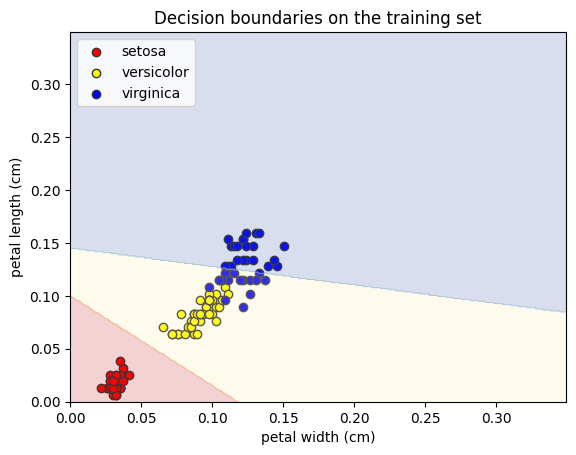

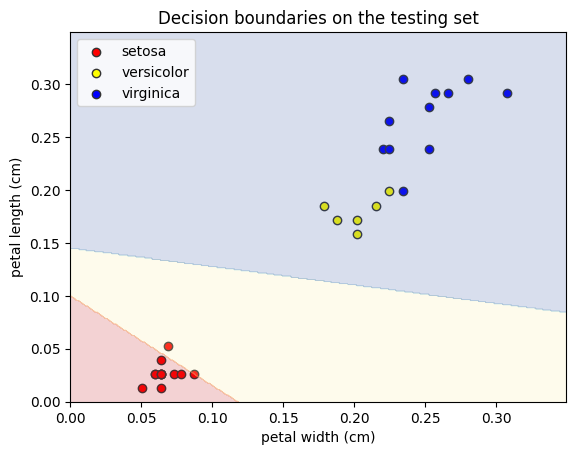

In [43]:
# Plot decision boundaries

def plot_boundaries(X, y, model, label_dict, feature_names, title, x_lims=(0.00, 0.35), y_lims=(0.00, 0.35), step=0.001):
    with torch.no_grad():
        # prep data
        label = y.argmax(1).squeeze()
        data_0 = X[label == 0][:, [1,2]]
        data_1 = X[label == 1][:, [1,2]]
        data_2 = X[label == 2][:, [1,2]]
        
        # plot data
        plt.scatter(data_0[:,0], data_0[:,1], edgecolor="#333", label=label_dict[0], c='red')
        plt.scatter(data_1[:,0], data_1[:,1], edgecolor="#333", label=label_dict[1], c='yellow')
        plt.scatter(data_2[:,0], data_2[:,1], edgecolor="#333", label=label_dict[2], c='blue')

        # plot meshgrid with predictions
        x1 = torch.arange(x_lims[0], x_lims[1], step=step)
        x2 = torch.arange(y_lims[0], y_lims[1], step=step)
        xx1, xx2 = torch.meshgrid(x1, x2)

        inputs = torch.stack([xx1.reshape(-1), xx2.reshape(-1)], dim=1)
        bias = torch.ones(inputs.shape[0], 1).float()
        inputs = torch.cat((bias, inputs), axis=-1)

        preds = log_reg(inputs).argmax(1)
        preds = preds.reshape(xx1.shape)

        # plot the decision boundaries
        plt.contourf(xx1.numpy(), xx2.numpy(), preds.numpy(), cmap=plt.cm.RdYlBu, alpha=0.2)

        # customize the plot
        plt.title(title)
        plt.ylabel(feature_names[2])
        plt.xlabel(feature_names[3])
        plt.legend(loc="upper left")
        plt.grid(False)

# Figure used for ploting the training data
plt.figure(1)
plot_boundaries(
    X_train, y_train, 
    log_reg, 
    label_dict,
    feature_names,
    "Decision boundaries on the training set",
    x_lims=(0.00, 0.35), y_lims=(0.00, 0.35), step=0.001
)

# Figure used for ploting the testing data
plt.figure(2)
plot_boundaries(
    X_test, y_test,
    log_reg,
    label_dict,
    feature_names,
    "Decision boundaries on the testing set",
    x_lims=(0.00, 0.35), y_lims=(0.00, 0.35), step=0.001
)

plt.show()

### 3. Final Challenge

In this lab script we gave you some introdutory notes on Machine Learning and provided the low-level implementation using Pytorch for two of the most basic algorithms within the field. Having understand all these basic tools, we want you to solve an issue using the Simpsons dataset. **We want to classify each one of the characters available in the dataset!**

Your final goal in this **final (and single)** assignment for this lab script is to provide the Python code to extract visual features from each one of the images in the dataset. **Use the multiclass logistic regression model to build a classifier that uses your extracted features.**

You will need to submit the following:
- source code for the feature extractor
- (*.pkl) file with the extracted features for the each image (check the appendix section on how to do that)
- **a justified explanation of the type of features that you used** (these features need to allow discriminating all characters in the dataset) - **Don't worry! The multiclass classifier does not need to obtain a 100% of Accuracy with your features! Our focus here is for you to learn...**

In [3]:
import os

# Search from your home directory
for root, dirs, files in os.walk(os.path.expanduser("~")):
    if "simpsons_split" in dirs:
        print(os.path.join(root, "simpsons_split"))
        break

/home/skaideer/COMUL/Lab 5 - Introduction to Machine Learning/data/simpsons_split


In [6]:
# Imports
from torch.utils.data import Dataset, DataLoader
from skimage.transform import resize
from skimage import io
from glob import glob
import numpy as np
import os


def load_image(f, size=(128, 128)):
    image = resize(io.imread(f), size)
    return torch.tensor(image)

def load_label(f):
    return os.path.split(os.path.split(f)[0])[1]

class SimpsonsDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        return x, y

    def __len__(self):
        return len(self.X)

# Set the data path
path = "/home/skaideer/COMUL/Lab 5 - Introduction to Machine Learning/data/simpsons_split"

label_dict = {
    "bart_simpson": 0.,
    "homer_simpson": 1.,
    "marge_simpson": 2.,
    "lisa_simpson": 3.
}


# Training Data Path
train_path = os.path.join(path, "train")
files = glob(os.path.join(train_path, "**/*"), recursive=True)
files = [f for f in files if not os.path.isdir(f)]
print(f"Found {len(files)} training files")

X_train = torch.stack([load_image(f) for i, f in enumerate(files) if not print(f"Loading train {i+1}/{len(files)}...", end="\r")])
y_train = torch.tensor([label_dict[load_label(f)] for f in files])

# Validation Data Path
test_path = os.path.join(path, "test")
files = glob(os.path.join(test_path, "**/*"), recursive=True)
files = [f for f in files if not os.path.isdir(f)]
print(f"\nFound {len(files)} test files")

X_test = torch.stack([load_image(f) for i, f in enumerate(files) if not print(f"Loading test {i+1}/{len(files)}...", end="\r")])
y_test = torch.tensor([label_dict[load_label(f)] for f in files])

print("\nDone!")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Found 4000 training files
Loading train 4000/4000...
Found 2233 test files
Loading test 2233/2233...
Done!
X_train: torch.Size([4000, 128, 128, 3]), X_test: torch.Size([2233, 128, 128, 3])


In [8]:
# Create our train and validation sets
train_dataset = SimpsonsDataset(X_train, y_train)
test_dataset = SimpsonsDataset(X_test, y_test)

# Use these sets to create our DataLoader(s)
train_loader = DataLoader(train_dataset, batch_size=32, num_workers=0, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=32, num_workers=0, shuffle=False, drop_last=False)

# Read each one of the elements
for (_X_train, _y_train), (_X_test, _y_test) in zip(train_loader, test_loader):
    print(f"X_train.shape: {_X_train.shape}, y_train.shape: {_y_train.shape}")
    print(f"X_test.shape: {_X_test.shape}, y_test.shape: {_y_test.shape}")
    break # just print one element

X_train.shape: torch.Size([32, 128, 128, 3]), y_train.shape: torch.Size([32])
X_test.shape: torch.Size([32, 128, 128, 3]), y_test.shape: torch.Size([32])


## References (development of this lab script)

This lab script was inspired from the tutorials/documentation from:

[a] Theodoridis, Sergios. Machine learning: a Bayesian and optimization perspective. Academic press, 2015. (**Main source of materials!**)

[b] Scripts from workshops presented in previous editions of the [CTM OpenDay at INESC TEC](https://opendayctm.inesctec.pt/)

[c] Scripts from introdutory course on Machine Learning by Prof. Jaime Cardoso at FEUP

[d] Deep Learning using Pytorch by [Andry Maykol Pinto](amgp@fe.up.pt) (Department of Electrical and Computer Engineering, FEUP)

## Appendix

### A. Pickle package

Using the pickle package you can save and load Python objects. Data is saved in .pkl files, which is a binary file.
The next code block, illustrates how to use the [pickle package](https://docs.python.org/3/library/pickle.html).

```python
import pickle

X_train_features    = torch.tensor(...)
Y_train             = torch.tensor(...)

X_test_features    = torch.tensor(...)
Y_test             = torch.tensor(...)

filepath = "data.pkl"

label_dict = {
    "bart_simpson": 0.,
    "homer_simpson": 1.,
    "marge_simpson": 2.,
    "lisa_simpson": 3.
}

# save object: wb means write to bytes
with open(filepath, 'wb') as file:
    pickle.dump(((X_train_features, Y_train), (X_test_features, Y_test), label_dict), file)

# load objects: rb means read from bytes
with open(filepath, 'rb') as file:
    ((X_train_features, Y_train), (X_test_features, Y_test), label_dict)= pickle.load(file)
```